In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [34]:
df = pd.read_csv('data.csv')
df.head()

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27820 entries, 0 to 27819
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             27820 non-null  object 
 1   year                27820 non-null  int64  
 2   sex                 27820 non-null  object 
 3   age                 27820 non-null  object 
 4   suicides_no         27820 non-null  int64  
 5   population          27820 non-null  int64  
 6   suicides/100k pop   27820 non-null  float64
 7   country-year        27820 non-null  object 
 8   HDI for year        8364 non-null   float64
 9    gdp_for_year ($)   27820 non-null  object 
 10  gdp_per_capita ($)  27820 non-null  int64  
 11  generation          27820 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 2.5+ MB


In [36]:
df.describe()

,year,suicides_no,population,suicides/100k pop,HDI for year,gdp_per_capita ($)
count,27820.000000,27820.000000,2.782000e+04,27820.000000,8364.000000,27820.000000
mean,2001.258375,242.574407,1.844794e+06,12.816097,0.776601,16866.464414
std,8.469055,902.047917,3.911779e+06,18.961511,0.093367,18887.576472
min,1985.000000,0.000000,2.780000e+02,0.000000,0.483000,251.000000
25%,1995.000000,3.000000,9.749850e+04,0.920000,0.713000,3447.000000
50%,2002.000000,25.000000,4.301500e+05,5.990000,0.779000,9372.000000
75%,2008.000000,131.000000,1.486143e+06,16.620000,0.855000,24874.000000
max,2016.000000,22338.000000,4.380521e+07,224.970000,0.944000,126352.000000


In [37]:
df.isnull().sum()

,0
country,0
year,0
sex,0
age,0
suicides_no,0
population,0
suicides/100k pop,0
country-year,0
HDI for year,19456
gdp_for_year ($),0


In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df = df.drop_duplicates()

In [53]:
X = df.drop('suicides_no', axis=1)
y = df['suicides_no']

In [54]:
print(len(X_train), len(y_train))

6691 6691


In [55]:
pd.get_dummies(df)

,year,suicides_no,population,suicides/100k pop,HDI for year,gdp_per_capita ($),country_Albania,country_Antigua and Barbuda,country_Argentina,country_Armenia,...,"gdp_for_year ($) _98,478,349,315","gdp_for_year ($) _99,697,566,668","gdp_for_year ($) _99,853,528,653","gdp_for_year ($) _99,886,577,331",generation_Boomers,generation_G.I. Generation,generation_Generation X,generation_Generation Z,generation_Millenials,generation_Silent
72,1995,13,232900,5.58,0.619,835,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
73,1995,9,178000,5.06,0.619,835,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
74,1995,2,40800,4.90,0.619,835,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
75,1995,13,283500,4.59,0.619,835,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
76,1995,11,241200,4.56,0.619,835,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27815,2014,107,3620833,2.96,0.675,2309,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
27816,2014,9,348465,2.58,0.675,2309,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
27817,2014,60,2762158,2.17,0.675,2309,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
27818,2014,44,2631600,1.67,0.675,2309,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [56]:
df = df.dropna()

In [57]:
X = df[['suicides_no']]
y = df['suicides_no']

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [59]:
print(model.intercept_)

1.7053025658242404e-13


In [60]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
suicides_no,1.0


In [61]:
y_pred = model.predict(X_test)

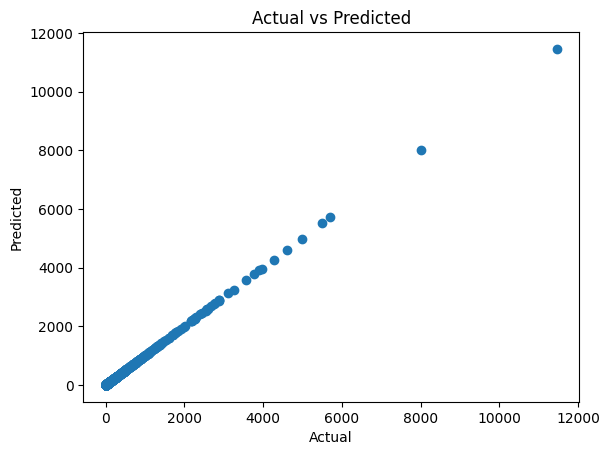

In [62]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 2.1787844823130942e-13
MSE: 2.4616690704003774e-25
RMSE: 4.961521007111002e-13
